##### NAME - KOMAL GUPTA
##### ROLL NO. & DIV - A(57)
##### PRN - 72258047K

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import vgg19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

In [2]:
# Load and preprocess image

def load_img(path, max_dim=512):
    img = image.load_img(path)
    img = image.img_to_array(img)

    shape = img.shape[:-1]
    long_dim = max(shape)
    scale = max_dim / long_dim
    new_shape = tuple((np.array(shape) * scale).astype(int))

    img = tf.image.resize(img, new_shape)
    img = np.expand_dims(img.numpy().copy(), axis=0)   # important fix

    return tf.keras.applications.vgg19.preprocess_input(img)

In [3]:
# Display image

def deprocess_img(processed_img):
    x = processed_img.copy()
    x = x.reshape((x.shape[1], x.shape[2], 3))

    # Reverse preprocessing
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68

    x = x[:, :, ::-1]
    x = np.clip(x, 0, 255).astype("uint8")

    return x


In [4]:
# Content and Style Loss

def content_loss(base_content, target):
    return tf.reduce_mean(tf.square(base_content - target))

def gram_matrix(input_tensor):
    channels = int(input_tensor.shape[-1])
    a = tf.reshape(input_tensor, [-1, channels])
    gram = tf.matmul(a, a, transpose_a=True)
    return gram

def style_loss(base_style, target):
    gram_style = gram_matrix(base_style)
    gram_target = gram_matrix(target)
    return tf.reduce_mean(tf.square(gram_style - gram_target))

In [5]:
# Build VGG model

content_layers = ['block5_conv2']
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1',
                'block4_conv1', 'block5_conv1']

vgg = vgg19.VGG19(weights='imagenet', include_top=False)
vgg.trainable = False

outputs = [vgg.get_layer(name).output for name in style_layers + content_layers]
model = Model([vgg.input], outputs)

In [6]:
# Feature extraction

def get_features(img):
    return model(img)

In [7]:
# Neural Style Transfer

def neural_style_transfer(content_path, style_path, epochs=100):
    content_img = load_img(content_path)
    style_img = load_img(style_path)

    content_features = get_features(content_img)
    style_features = get_features(style_img)

    generated_img = tf.Variable(content_img, dtype=tf.float32)

    optimizer = tf.optimizers.Adam(learning_rate=2.0)

    style_weight = 1e-2
    content_weight = 1e4

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            gen_features = get_features(generated_img)

            c_loss = content_loss(content_features[-1], gen_features[-1])

            s_loss = 0
            for i in range(len(style_layers)):
                s_loss += style_loss(style_features[i], gen_features[i])

            total_loss = content_weight * c_loss + style_weight * s_loss

        grad = tape.gradient(total_loss, generated_img)
        optimizer.apply_gradients([(grad, generated_img)])

        generated_img.assign(tf.clip_by_value(generated_img, -128, 128))

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss.numpy()}")

    final_img = deprocess_img(generated_img.numpy())

    plt.imshow(final_img)
    plt.axis("off")
    plt.title("Stylized Image")
    plt.show()

C:\Users\sourbh gupta\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 367, 511, 3))
  warnings.warn(msg)
C:\Users\sourbh gupta\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 338, 512, 3))
  warnings.warn(msg)


Epoch 0, Loss: 8592377891520512.0
Epoch 10, Loss: 2275853241155584.0
Epoch 20, Loss: 809228411338752.0
Epoch 30, Loss: 343932089139200.0
Epoch 40, Loss: 187442992775168.0
Epoch 50, Loss: 126357921071104.0
Epoch 60, Loss: 91440214441984.0
Epoch 70, Loss: 69534715215872.0
Epoch 80, Loss: 55852727795712.0
Epoch 90, Loss: 46437400313856.0


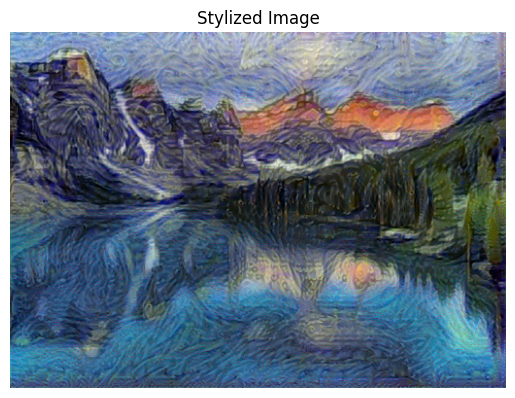

In [8]:
# Run

neural_style_transfer("content_img.jpg", "style_img.jpg")